In [82]:
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import networkx as nx

from RRAM import Representate as rp
from RRAM.Representate import config_ax, setup_paper_plt
from RRAM.Representate import RepresentateState

from pathlib import Path

In [83]:
def encontrar_primer_matriz(num_simulation: int, tipo_fase: str = "sp_set"):
    """
    Busca el primer archivo de temperatura que contiene una matriz (2D).
    Para cuando lo encuentra.

    Args:
        num_simulation: Número de la simulación
        tipo_fase: Tipo de fase ('pp_set' para primera parte del set)

    Returns:
        tuple: (nombre_archivo, paso, temperatura_matriz) o (None, None, None) si no encuentra
    """
    figures_path = Path(f"Results/simulation_{num_simulation}/Figures/")
    archivos = sorted(figures_path.glob(f"temperatura_*_{tipo_fase}.npy"))

    for archivo in archivos:
        temperatura = np.load(archivo)

        if temperatura.ndim == 2:  # Es una matriz
            # Extraer el número de paso del nombre del archivo
            paso = int(archivo.stem.split("_")[1])
            print(f"✓ Primer matriz encontrada: {archivo.name}")
            print(f"  Paso: {paso}")
            print(f"  Shape: {temperatura.shape}")
            return archivo.name, paso, temperatura

    print("✗ No se encontró ninguna matriz")
    return None, None, None


# Uso
filename, paso, temperatura = encontrar_primer_matriz(num_simulation=12, tipo_fase="sp_set")

if filename:
    print(f"\nTemperatura media: {temperatura.mean():.2f} K")
    print(f"Temperatura máxima: {temperatura.max():.2f} K")


✓ Primer matriz encontrada: temperatura_0_sp_set.npy
  Paso: 0
  Shape: (100, 102)

Temperatura media: 551.89 K
Temperatura máxima: 828.29 K


In [84]:
def extraer_mapa_evolucion_temperatura(lista_matrices, columna_x):
    """
    Toma una lista de matrices 2D y extrae la columna 'columna_x' de cada una,
    formando una matriz 2D de forma (Ny, num_pasos).
    """
    # Repaso toda la lista dada buscanso si algun elemento es un número en luar de una matri
    for i, m in enumerate(lista_matrices):
        if isinstance(m, (int, float)):
            print(f"⚠️ Advertencia: Elemento en la posición {i} es un número ({m}), no una matriz. Se omitirá.")
        if not isinstance(m, np.ndarray) or m.ndim != 2:
            print(f"⚠️ Advertencia: Elemento en la posición {i} no es una matriz 2D. Se omitirá.")

    # Extraemos la columna seleccionada de cada matriz y las apilamos horizontalmente
    # Resultado: filas = posición vertical, columnas = pasos de simulación
    mapa_evolucion = np.column_stack([m[:, columna_x] for m in lista_matrices])
    
    
    return mapa_evolucion


In [85]:
def plot_heatmap_evolucion(
    mapa_evolucion,
    atom_size,
    etiquetas_x,
    columna_x,
    title="Evolución del Perfil Térmico",
    save_path=None,
    usar_latex=True,
    scaling=2.5,
):
    """
    Representa un mapa de color de la evolución de la temperatura.
    Eje X: Paso de simulación (n)
    Eje Y: Posición vertical en el dispositivo (nm)
    Color: Temperatura (K)
    """
    # Aplicamos tu configuración global
    setup_paper_plt(plt, latex=usar_latex, scaling=scaling)

    Ny, num_pasos = mapa_evolucion.shape
    distancias_y = np.arange(Ny) * atom_size

    fig, ax = plt.subplots(figsize=(14, 10))
    config_ax(ax)

    # Dibujamos el mapa de calor
    # origin='lower' asegura que la base del dispositivo (fila 0) esté abajo
    # extent define los límites físicos de los ejes para que coincidan con tus datos
    im = ax.imshow(
        mapa_evolucion,
        aspect="auto",
        origin="lower",
        cmap="coolwarm",
        # extent=[-0.5, num_pasos - 0.5, distancias_y[0], distancias_y[-1]],
    )

    # Añadimos la barra de colores (Colorbar)
    cbar = fig.colorbar(im, ax=ax, pad=0.02)
    cbar.set_label(r"Temperature (K)")

    # Configuración de etiquetas
    ax.set_xlabel(r"Simulation Step ($n$)")
    ax.set_ylabel(r"Vertical Distance (\si{\nano\meter})")
    ax.set_title(f"{title} (Columna {columna_x})", pad=20)
    
    # Dibujo una linea horizontal para marcar el 30
    ax.axhline(y=30, color='black', linestyle='--', linewidth=1)

    # Colocamos tus etiquetas personalizadas (valores manuales) en el eje X
    # ax.set_xticks(np.arange(num_pasos))
    # ax.set_xticklabels(etiquetas_x, rotation=45)

    plt.tight_layout()

    if save_path:
        os.makedirs(os.path.dirname(save_path), exist_ok=True)
        plt.savefig(save_path, dpi=300, bbox_inches="tight")

    plt.show()


✓ Primer matriz encontrada: temperatura_0_sp_set.npy
  Paso: 0
  Shape: (100, 102)
('temperatura_0_sp_set.npy', 0, array([[300.        , 309.09971111, 324.48685017, ..., 324.09495883,
        308.95434995, 300.        ],
       [300.        , 310.50585147, 324.88089311, ..., 324.4835481 ,
        310.33839428, 300.        ],
       [300.        , 310.52238842, 324.91997344, ..., 324.52374738,
        310.3554256 , 300.        ],
       ...,
       [300.        , 304.88434472, 311.56965143, ..., 311.0997846 ,
        304.68568924, 300.        ],
       [300.        , 304.87878072, 311.55647856, ..., 311.08876961,
        304.68103844, 300.        ],
       [300.        , 304.22669625, 311.37591869, ..., 310.91632444,
        304.05568048, 300.        ]]))
Iniciando carga de matrices para la simulación 12...
Procesando paso 0...
Procesando paso 500...
Procesando paso 1000...
Procesando paso 1500...
Procesando paso 2000...
Procesando paso 2500...
Procesando paso 3000...
Procesando paso 35

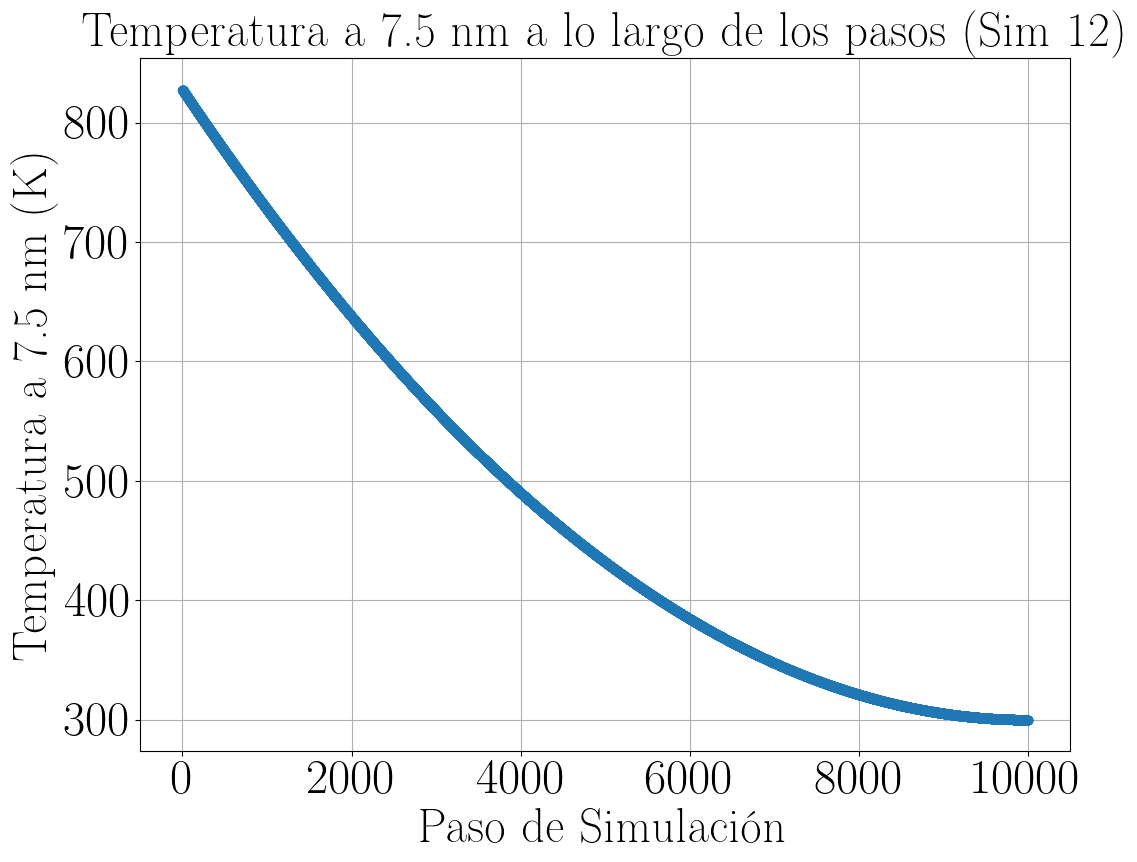

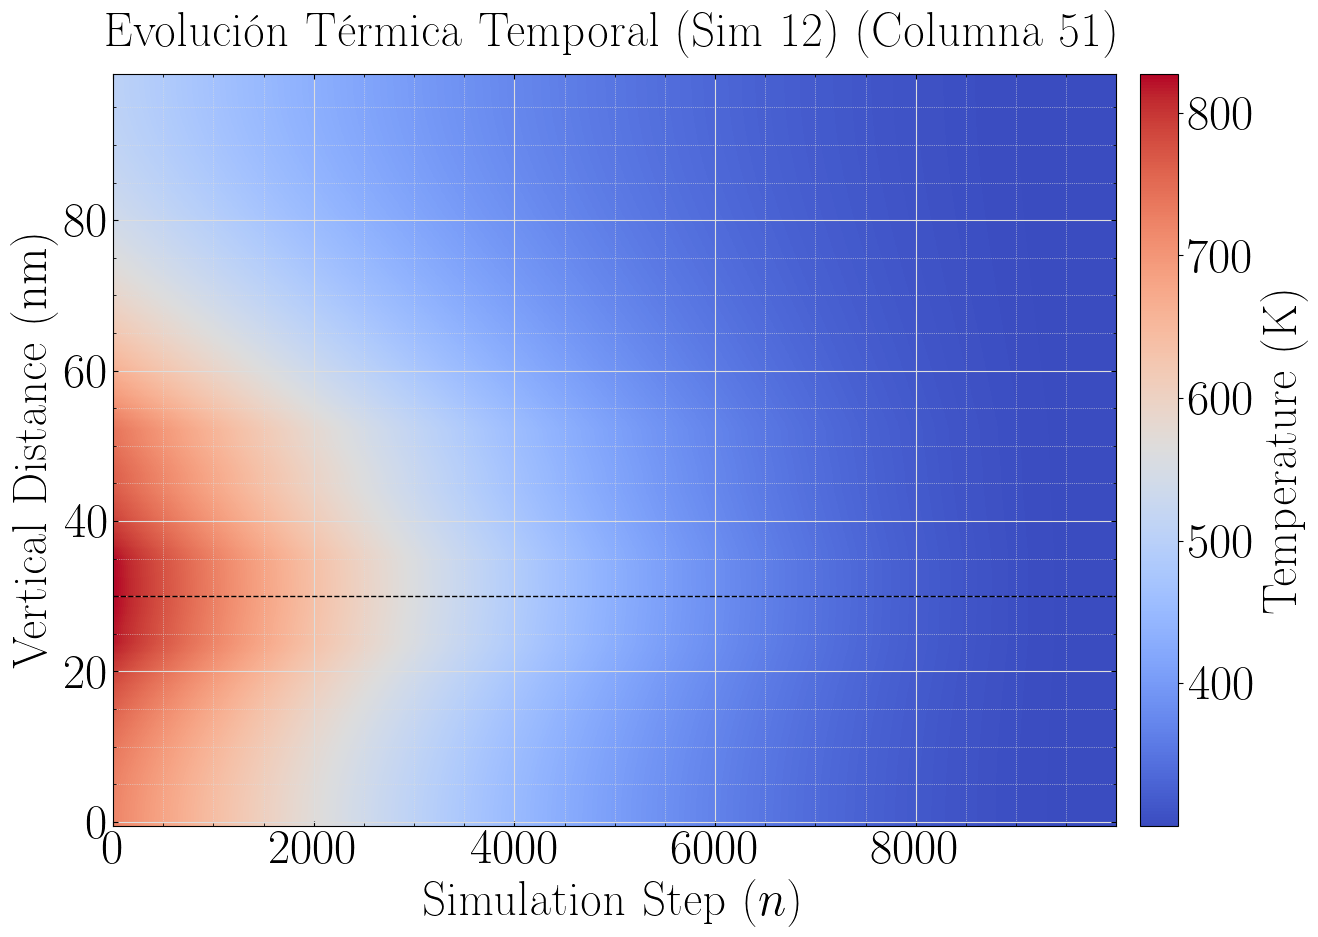

In [86]:
# --- PARÁMETROS DE CONFIGURACIÓN ---
num_simulation = 12  # Simulación que quieres analizar
rango_pasos = range(0, 9999)  # Desde 5822 hasta 10000
atom_size = 0.25
columna_evaluar = 51
base_path = f"C:/Users/Usuario/Documents/GitHub/RRAM_Simulation/Results/simulation_{num_simulation}/Figures/"

print(encontrar_primer_matriz(num_simulation=num_simulation, tipo_fase="sp_set"))

lista_matrices = []
etiquetas_pasos = []

print(f"Iniciando carga de matrices para la simulación {num_simulation}...")

# --- BUCLE DE CARGA DE DATOS ---
for paso in rango_pasos:
    # Construir el nombre del archivo según tu nueva nomenclatura
    filename_temp = f"temperatura_{paso}_sp_set.npy"
    file_path = os.path.join(base_path, filename_temp)

    if os.path.exists(file_path):
        try:
            matriz = np.load(file_path)
            lista_matrices.append(matriz)
            # Guardamos el número de paso como etiqueta para el eje X
            etiquetas_pasos.append(str(paso))
        except Exception as e:
            print(f"Error al cargar el paso {paso}: {e}")

    # Opcional: imprimir progreso cada 500 pasos para saber que el script avanza
    if paso % 500 == 0:
        print(f"Procesando paso {paso}...")

if not lista_matrices:
    print("No se encontraron matrices en el rango especificado. Revisa la ruta y los nombres.")
else:
    print(f"Carga finalizada: {len(lista_matrices)} matrices listas para procesar.")

# print(lista_matrices)
# 1. Creamos la matriz de evolución (Ny x Cantidad de Pasos)
mapa_datos = extraer_mapa_evolucion_temperatura(lista_matrices, columna_evaluar)

# Obtengo del mapa de temperatura la temperatura a 30
posiciones_y = np.arange(mapa_datos.shape[0])
temperatura_a_30 = mapa_datos[30, :]

print(f"Temperatura a 30 a lo largo de los pasos: {temperatura_a_30}")

# Ploteo esa temperatura
plt.figure(figsize=(12, 9))
plt.plot(rango_pasos, temperatura_a_30, marker="o")
plt.xlabel("Paso de Simulación")
posicion = 30 * atom_size  # Convertimos la posición en nm
plt.ylabel(f"Temperatura a {posicion} nm (K)")
plt.title(f"Temperatura a {posicion} nm a lo largo de los pasos (Sim {num_simulation})")
plt.grid()

# 2. Generamos el heatmap
# Nota: Si hay muchos pasos (ej. 4000), el eje X puede saturarse.
# El script plot_heatmap_evolucion manejará la escala automáticamente.
plot_heatmap_evolucion(
    mapa_evolucion=mapa_datos,
    atom_size=atom_size,
    etiquetas_x=etiquetas_pasos,
    columna_x=columna_evaluar,
    title=f"Evolución Térmica Temporal (Sim {num_simulation})",
    save_path=f"C:/Users/Usuario/Documents/GitHub/RRAM_Simulation/Heatmap_Temporal_Sim{num_simulation}.png",
)
